In [1]:
import shutil
import warnings

warnings.filterwarnings('ignore')

import os

import numpy as np
import torch

import ViMST as vim 
from pathlib import Path
import scanpy as sc
import pandas as pd
from sklearn import metrics
from utils import refine
import matplotlib.pyplot as plt

def train_one(args, adata, tissue_name=' '):
    net = vim.ViMST(adata,
                     tissue_name=tissue_name,
                     num_clusters=args.n_clusters,
                     genes_model='pca',
                     top_genes=args.top_genes,
                     rad_cutoff=args.rad_cutoff,
                     k_cutoff=args.k_cutoff,
                     graph_model='KNN',   #Radius
                     device=torch.device('cuda:0' if torch.cuda.is_available() else 'cpu'),
                     learning_rate=args.learning_rate,
                     weight_decay=args.weight_decay,
                     max_epoch=args.max_epoch,
                     gradient_clipping=args.gradient_clipping,
                     feat_mask_rate=args.feat_mask_rate,
                     img_mask_rate=args.img_mask_rate,
                     edge_drop_rate=args.edge_drop_rate,
                     hidden_dim=args.hidden_dim,
                     latent_dim=args.latent_dim,
                     bn=args.bn,
                     att_dropout_rate=args.att_dropout_rate,
                     fc_dropout_rate=args.fc_dropout_rate,
                     use_token=args.use_token,
                     rep_loss=args.rep_loss,
                     rel_loss=args.rel_loss,
                     alpha=args.alpha,
                     lam=args.lam,
                     random_seed=args.seed, 
                     nps=args.nps)
    net.train()
    method = "kmeans"
    net.process(method=method)
    # net.clustering(method=method)
    adata = net.get_adata()
    '''
    adata.obs["refined_pred"] = vim.utils.spatial_domains_refinement_ez_mode(sample_id=adata.obs.index.tolist(),
                                                                       pred=adata.obs["kmeans"].tolist(), x_array=adata.obs['array_row'],
                                                                       y_array=adata.obs['array_col'], shape="hexagon")
    adata.obs["refined_pred"] = adata.obs["refined_pred"].astype('category')
    ''' 

    #adata.obs[method] = vim.utils.refine_label(adata, radius=50, key=method)

    # 使用 refine 函数细化预测
    #refined_pred = refine(adata, adata.obs[method], shape="hexagon")  # refine 函数的调用
    #adata.obs[method] = refined_pred  # 存储细化后的预测结果
    # 更新 adata.obs 中的预测值
    #adata.obs['refined_pred'] = refined_pred  # 存储细化后的预测结果
    print(f"adata.obsm['eval_pred'].shape:{adata.obsm['eval_pred'].shape}")
    return adata

In [2]:


from ViMST.utils import build_args

# 初始化其他参数
args = build_args()
args.hidden_dim, args.latent_dim = 512, 256
args.max_epoch = 500
args.top_genes = 3000
args.n_clusters = 26
args.lam = 1
args.feat_mask_rate = 0.4
args.img_mask_rate = 0.4
#最佳 
args.k_cutoff = 6   #定了k为6

args.nps = 19 #定了20
args.edge_drop_rate = 0.2 #定了
# 数据路径


tissue_name = "brainback"

count_file = "V1_Mouse_Brain_Sagittal_Posterior_filtered_feature_bc_matrix.h5"
adata = sc.read_h5ad("/home/dingcheng/data/mousebackfront/filtered_feature_bc_matrix.h5ad")


In [3]:
adata = train_one(args, adata, tissue_name)

adata.obsm['feat'].shape:(6050, 150)
gene_recon 1维度: torch.Size([2695, 3000])
gene_recon 2维度: torch.Size([3355, 3000])
拼接后的维度: (6050, 150)
adata.obsm['fea1'].shape:(6050, 150)
------Calculating spatial graph...
The graph contains 36300 edges, 6050 cells.
6.0000 neighbors per cell on average.
(6050, 150)


Dataset_Name:brainback, Ep 499: train loss:0.3128: 100%|██████████| 500/500 [00:16<00:00, 29.63it/s]


adata.obsm['eval_pred'].shape:(6050, 38)


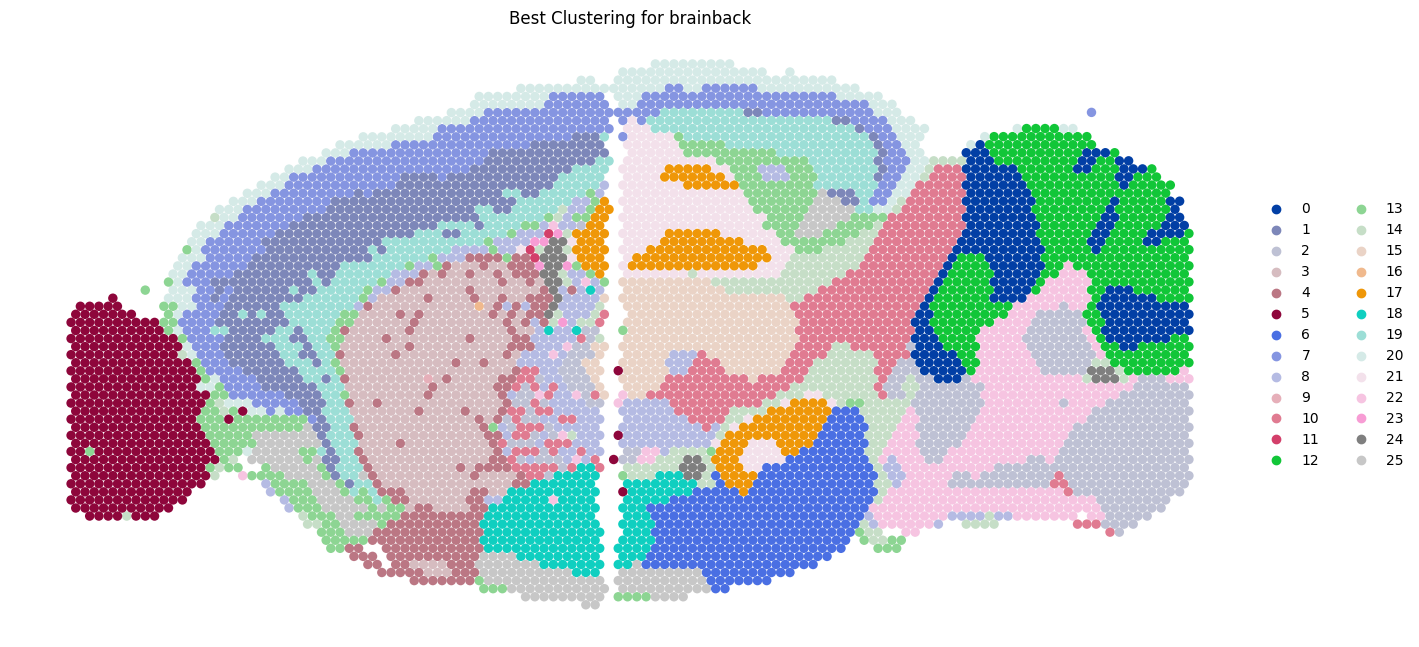

In [4]:
# 绘制最佳配置下的聚类图
fig, ax = plt.subplots(figsize=(16, 8))
sc.pl.spatial(adata, color=['kmeans'], show=False, spot_size=140, ax=ax)
ax.set_title(f"Best Clustering for {tissue_name}") 
ax.axis('off')
plt.show()

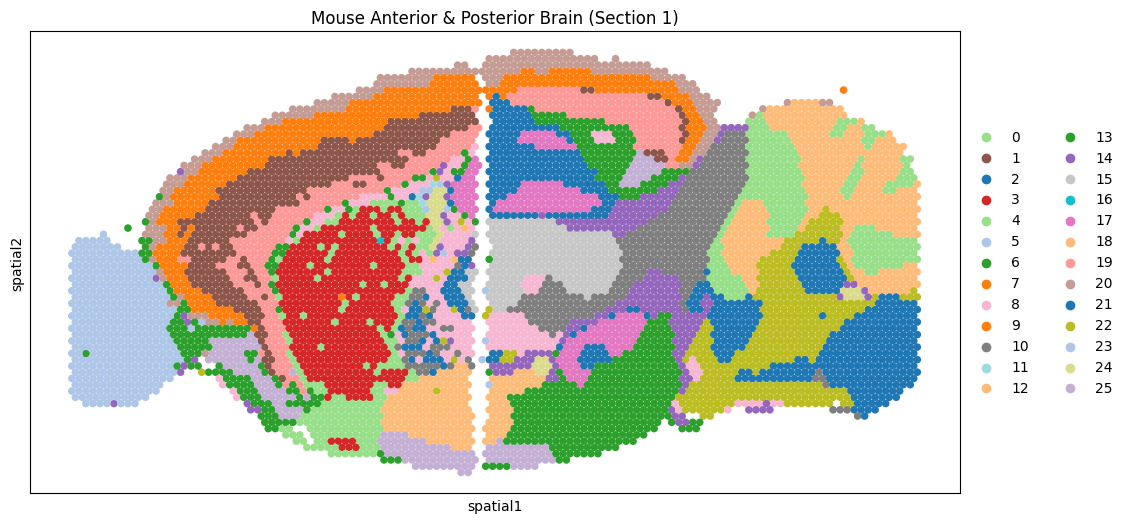

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# 将坐标轴Y翻转，假设原始数据的Y轴方向需要调整
adata.obsm['spatial'][:, 1] = -1 * adata.obsm['spatial'][:, 1]

# 使用 tab20 调色板，根据 'domain' 的唯一值数量分配颜色
rgb_values = sns.color_palette("tab20", len(adata.obs['kmeans'].unique()))

# 创建一个字典，将每个 'domain' 映射到一个颜色
color_fine = dict(zip(list(adata.obs['kmeans'].unique()), rgb_values))

# 设置图形的大小
plt.rcParams["figure.figsize"] = (12, 6)

# 绘制空间聚类结果
sc.pl.embedding(adata, basis="spatial",
                color="kmeans",
                s=120,
                palette=color_fine,
                show=False,
                title='Mouse Anterior & Posterior Brain (Section 1)')
ax.invert_yaxis()  # 翻转y轴

# 保存图像为 PDF，600 dpi，指定保存路径
save_path = '/home/Data/mouse_backfront/clustering_result.pdf'  # 指定保存路径
os.makedirs(os.path.dirname(save_path), exist_ok=True)  # 确保目录存在
plt.savefig(save_path, dpi=600, bbox_inches='tight', format='pdf')  # 保存为 PDF 格式，600

plt.show()



In [6]:
output_path = "/home/Data/mouse_backfront/brainbackfront_processed.h5ad"
adata.write(output_path)


In [8]:
from s_dbw import S_Dbw
# 然后将其转换为有序类别
adata.obs["kmeans"] = adata.obs["kmeans"].cat.as_ordered()


dav = metrics.davies_bouldin_score(adata.obsm['eval_pred'], adata.obs["kmeans"])
cal = metrics.calinski_harabasz_score(adata.obsm['eval_pred'], adata.obs["kmeans"])
sil = metrics.silhouette_score(adata.obsm['eval_pred'], adata.obs["kmeans"])



sdbw = np.round(S_Dbw(adata.obsm['eval_pred'], adata.obs["kmeans"]), 5)
# Ann_df = pd.read_csv('./metadata.tsv', sep='\t')
# ARI = np.round(metrics.adjusted_rand_score(y_pred, Ann_df['fine_annot_type']), 3)
# NMI = np.round(metrics.normalized_mutual_info_score(y_pred, Ann_df['fine_annot_type']), 3)
print("dav:", dav)
print("cal:", cal)
print("sil:", sil)
print("sdbw:", sdbw)

dav: 1.6234201005435642
cal: 609.9043849069917
sil: 0.1764047
sdbw: 0.59963
